<a href="https://colab.research.google.com/github/soonhyeong/NVIDIA_AI_Edu/blob/main/012_project7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 기본 셋업 (맨 처음 한 번 실행)
!pip install -q koreanize-matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False
print("준비 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 31.4 MB/s eta 0:00:00
준비 완료


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATA/sleeping_hours.csv", encoding = "euc-kr")
df.head()

,응답자유형별(1),응답자유형별(2),2021,2021.1,2021.2,2021.3,2021.4,2021.5,2021.6
0,응답자유형별(1),응답자유형별(2),5시간 미만 (%),5~6시간 (%),6~7시간 (%),7~8시간 (%),8~9시간 (%),9시간 이상 (%),평균 (시간)
1,전체,소계,9.6,15.1,17.9,19.0,20.3,18.0,7.2
2,성별,남자,7.3,13.5,17.8,19.4,22.1,19.8,7.3
3,성별,여자,12.2,16.9,18.0,18.6,18.3,16.0,7.0
4,학교급,초등학교,0.7,1.8,4.3,14.0,33.5,45.7,8.7


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATA/sleeping_hours.csv", encoding = "euc-kr", header=[0,1])
df.head()

응답자유형별(1) 응답자유형별(2)       2021                                          \
  응답자유형별(1) 응답자유형별(2) 5시간 미만 (%) 5~6시간 (%) 6~7시간 (%) 7~8시간 (%) 8~9시간 (%)   
0        전체        소계        9.6      15.1      17.9      19.0      20.3   
1        성별        남자        7.3      13.5      17.8      19.4      22.1   
2        성별        여자       12.2      16.9      18.0      18.6      18.3   
3       학교급      초등학교        0.7       1.8       4.3      14.0      33.5   
4       학교급       중학교        6.2      12.2      22.1      30.0      22.6   

                      
  9시간 이상 (%) 평균 (시간)  
0       18.0     7.2  
1       19.8     7.3  
2       16.0     7.0  
3       45.7     8.7  
4        6.8     7.1

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATA/sleeping_hours.csv", encoding = "euc-kr", index_col=[0,1])
df.head()

2021     2021.1     2021.2     2021.3     2021.4  \
응답자유형별(1) 응답자유형별(2)                                                           
응답자유형별(1) 응답자유형별(2)  5시간 미만 (%)  5~6시간 (%)  6~7시간 (%)  7~8시간 (%)  8~9시간 (%)   
전체        소계                9.6       15.1       17.9       19.0       20.3   
성별        남자                7.3       13.5       17.8       19.4       22.1   
          여자               12.2       16.9       18.0       18.6       18.3   
학교급       초등학교              0.7        1.8        4.3       14.0       33.5   

                         2021.5   2021.6  
응답자유형별(1) 응답자유형별(2)                       
응답자유형별(1) 응답자유형별(2)  9시간 이상 (%)  평균 (시간)  
전체        소계               18.0      7.2  
성별        남자               19.8      7.3  
          여자               16.0      7.0  
학교급       초등학교             45.7      8.7

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATA/sleeping_hours.csv", encoding = "euc-kr", header=[0,1],index_col=[0,1])
df.head()

응답자유형별(1)       2021                                                     \
응답자유형별(1) 5시간 미만 (%) 5~6시간 (%) 6~7시간 (%) 7~8시간 (%) 8~9시간 (%) 9시간 이상 (%)   
전체  소계           9.6      15.1      17.9      19.0      20.3       18.0   
성별  남자           7.3      13.5      17.8      19.4      22.1       19.8   
    여자          12.2      16.9      18.0      18.6      18.3       16.0   
학교급 초등학교         0.7       1.8       4.3      14.0      33.5       45.7   
    중학교          6.2      12.2      22.1      30.0      22.6        6.8   

응답자유형별(1)          
응답자유형별(1) 평균 (시간)  
전체  소계        7.2  
성별  남자        7.3  
    여자        7.0  
학교급 초등학교      8.7  
    중학교       7.1

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATA/sleeping_hours.csv", encoding = "euc-kr", header=[0,1],index_col=[0,1])
df = df.T
df = df.rename_axis(index =["연도", "수면시간"])
df
#df["학업성적"].loc["2021", "상"]

전체    성별         학교급              고교유형        지역규모        \
                   소계    남자    여자  초등학교   중학교  고등학교  일반계고 특성화계고   대도시  중소도시   
연도   수면시간                                                                     
2021 5시간 미만 (%)   9.6   7.3  12.2   0.7   6.2  22.0  23.4  16.6  11.3   8.1   
     5~6시간 (%)   15.1  13.5  16.9   1.8  12.2  31.5  34.6  19.1  15.8  13.0   
     6~7시간 (%)   17.9  17.8  18.0   4.3  22.1  27.4  26.7  30.1  18.5  17.0   
     7~8시간 (%)   19.0  19.4  18.6  14.0  30.0  13.2  11.1  21.5  19.3  19.6   
     8~9시간 (%)   20.3  22.1  18.3  33.5  22.6   4.7   3.4   9.8  18.6  22.7   
     9시간 이상 (%)  18.0  19.8  16.0  45.7   6.8   1.2   0.8   2.9  16.6  19.6   
     평균 (시간)      7.2   7.3   7.0   8.7   7.1   5.8   5.7   6.3   7.0   7.3   

                 ...  가족유형                    학업성적             경제적 수준        \
                 ... 양부모가정 한부모가정  조손가정    기타     상     중     하      상     중   
연도   수면시간        ...                                                          
2021 5시간 미만 (%)  ...   9.6  13.0   0.8   4.5   5.7   9.4  16.8    7.6  11.1   
     5~6시간 (%)   ...  15.1  18.8   4.1   6.8  12.0  14.9  20.9   12.7  17.4   
     6~7시간 (%)   ...  17.6  23.3  14.3  13.5  15.1  17.9  22.7   15.6  20.2   
     7~8시간 (%)   ...  18.8  20.2  22.6  24.2  18.5  19.3  19.4   18.2  21.7   
     8~9시간 (%)   ...  20.7  13.6  25.7  18.9  24.1  20.3  13.8   23.1  16.9   
     9시간 이상 (%)  ...  18.1  11.0  32.5  32.2  24.5  18.3   6.4   22.7  12.6   
     평균 (시간)     ...   7.2   6.7   8.2   7.8   7.6   7.2   6.4    7.4   6.9   

                       
                    하  
연도   수면시간              
2021 5시간 미만 (%)  17.7  
     5~6시간 (%)   23.7  
     6~7시간 (%)   25.1  
     7~8시간 (%)   13.6  
     8~9시간 (%)   13.5  
     9시간 이상 (%)   6.3  
     평균 (시간)      6.3  

[7 rows x 21 columns]

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATA/sleeping_hours.csv", encoding = "euc-kr", header=[0,1],index_col=[0,1])
df = df.T
df = df.rename_axis(index =["연도", "수면시간"])
df["학업성적"].iloc[:6]

상     중     하
연도   수면시간                        
2021 5시간 미만 (%)   5.7   9.4  16.8
     5~6시간 (%)   12.0  14.9  20.9
     6~7시간 (%)   15.1  17.9  22.7
     7~8시간 (%)   18.5  19.3  19.4
     8~9시간 (%)   24.1  20.3  13.8
     9시간 이상 (%)  24.5  18.3   6.4

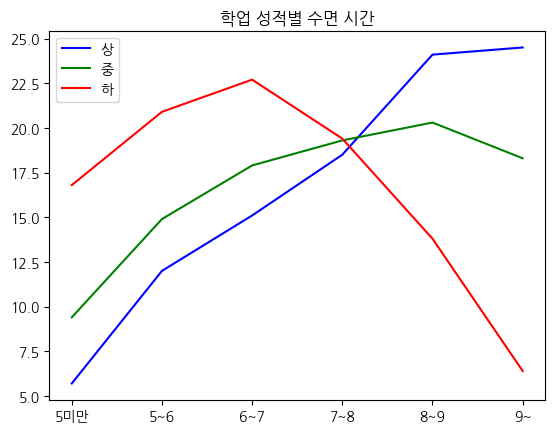

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DATA/sleeping_hours.csv", encoding = "euc-kr", header=[0,1],index_col=[0,1])
df = df.T
df = df.rename_axis(index =["연도", "수면시간"])

times = ["5미만","5~6","6~7","7~8","8~9","9~"]

high_2021 = df["학업성적"].iloc[:6, 0]
middle_2021 = df["학업성적"].iloc[:6, 1]
row_2021 = df["학업성적"].iloc[:6, 2]

#print(high_2021)
#print(middle_2021)
#print(row_2021)

plt.title("학업 성적별 수면 시간")
plt.plot(times, high_2021, label = '상', color = 'blue')
plt.plot(times, middle_2021, label = '중', color = 'green')
plt.plot(times, row_2021, label = '하', color = 'red')

plt.legend()
plt.show()